In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

print(performance.shape)

performance.head()

(40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [2]:
metrics = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct',
    'max_drawdown_pct',
    'expense_ratio_pct'
]

performance[metrics].describe()

,return_1yr_pct,return_3yr_pct,return_5yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,expense_ratio_pct
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,14.376000,14.089000,14.516750,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,1.237000
std,4.883023,4.617253,4.454021,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,0.386584
min,4.260000,5.140000,5.430000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,0.550000
25%,11.735000,12.035000,12.340000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,0.787500
50%,14.620000,14.205000,14.185000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,1.425000
75%,16.392500,15.882500,17.585000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,1.540000
max,24.930000,23.390000,23.800000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,1.640000


In [3]:
performance['performance_score'] = (
      performance['return_3yr_pct'] * 0.35
    + performance['return_5yr_pct'] * 0.35
    + performance['sharpe_ratio'] * 15
    + performance['alpha'] * 5
    - performance['expense_ratio_pct'] * 5
)

In [4]:
ranked_funds = (
    performance
    .sort_values(
        by='performance_score',
        ascending=False
    )
)

ranked_funds[
    [
        'scheme_name',
        'performance_score'
    ]
].head(10)

,scheme_name,performance_score
14,ICICI Pru Liquid Fund - Regular - Growth,126.2170
23,Kotak Liquid Fund - Regular - Growth,102.3540
30,ABSL Liquid Fund - Regular - Growth,83.6315
9,HDFC Short Term Debt Fund - Regular - Growth,39.5230
3,SBI Small Cap Fund - Direct Plan - Growth,31.7360
29,ABSL Small Cap Fund - Regular - Growth,31.2130
4,SBI Magnum Gilt Fund - Regular Plan - Growth,30.9750
21,Kotak Emerging Equity Fund - Regular - Growth,28.7430
2,SBI Small Cap Fund - Regular Plan - Growth,28.5210
16,Nippon India Large Cap Fund - Direct - Growth,27.5675


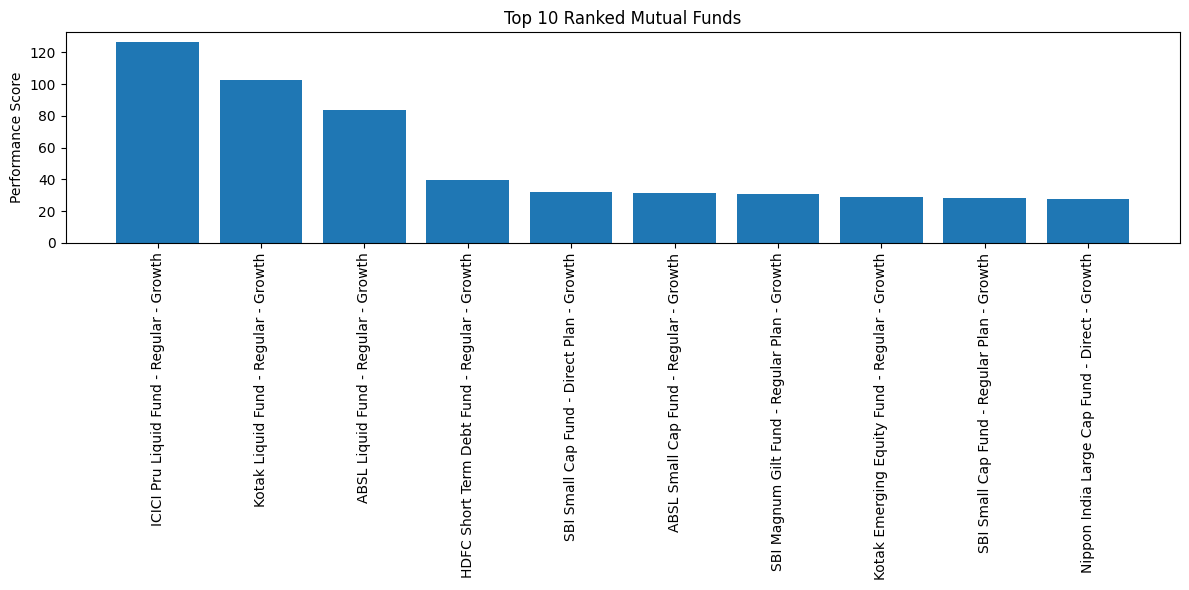

In [5]:
top10 = ranked_funds.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['performance_score']
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Ranked Mutual Funds"
)

plt.ylabel("Performance Score")

plt.tight_layout()

plt.show()

In [6]:
def classify_risk(beta):

    if beta < 0.8:
        return "Low Risk"

    elif beta < 1.0:
        return "Moderate Risk"

    else:
        return "High Risk"


ranked_funds["risk_level"] = (
    ranked_funds["beta"]
    .apply(classify_risk)
)

ranked_funds[
    [
        "scheme_name",
        "beta",
        "risk_level"
    ]
].head()

,scheme_name,beta,risk_level
14,ICICI Pru Liquid Fund - Regular - Growth,0.26,Low Risk
23,Kotak Liquid Fund - Regular - Growth,0.47,Low Risk
30,ABSL Liquid Fund - Regular - Growth,0.43,Low Risk
9,HDFC Short Term Debt Fund - Regular - Growth,0.44,Low Risk
3,SBI Small Cap Fund - Direct Plan - Growth,1.04,High Risk


In [7]:
low_risk = ranked_funds[
    ranked_funds["risk_level"] == "Low Risk"
].head(5)

moderate_risk = ranked_funds[
    ranked_funds["risk_level"] == "Moderate Risk"
].head(5)

high_risk = ranked_funds[
    ranked_funds["risk_level"] == "High Risk"
].head(5)

print("LOW RISK FUNDS")
print(
    low_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

print("\nMODERATE RISK FUNDS")
print(
    moderate_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

print("\nHIGH RISK FUNDS")
print(
    high_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

LOW RISK FUNDS
                                     scheme_name  performance_score
14      ICICI Pru Liquid Fund - Regular - Growth           126.2170
23          Kotak Liquid Fund - Regular - Growth           102.3540
30           ABSL Liquid Fund - Regular - Growth            83.6315
9   HDFC Short Term Debt Fund - Regular - Growth            39.5230
4   SBI Magnum Gilt Fund - Regular Plan - Growth            30.9750

MODERATE RISK FUNDS
                                      scheme_name  performance_score
29         ABSL Small Cap Fund - Regular - Growth            31.2130
2      SBI Small Cap Fund - Regular Plan - Growth            28.5210
22         Kotak Flexicap Fund - Regular - Growth            26.9025
1        SBI Bluechip Fund - Direct Plan - Growth            26.6855
34  Mirae Asset Large Cap Fund - Regular - Growth            26.3215

HIGH RISK FUNDS
                                      scheme_name  performance_score
3       SBI Small Cap Fund - Direct Plan - Growth       

In [8]:
ranked_funds.to_csv(
    "../data/processed/fund_rankings.csv",
    index=False
)

print(
    "fund_rankings.csv created successfully!"
)

fund_rankings.csv created successfully!


In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

print(nav.head())

print(nav.shape)

print(nav.columns.tolist())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
(46000, 3)
['amfi_code', 'date', 'nav']


In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code', 'date']
)

In [3]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [4]:
returns = nav[
    ['amfi_code',
     'date',
     'daily_return']
]

returns.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print(
    "returns_computed.csv created!"
)

returns_computed.csv created!


In [5]:
annual_returns = (
    nav.groupby('amfi_code')
    .apply(
        lambda x:
        (
            (1 + x['daily_return'].dropna())
            .prod()
        ) ** (252 / len(x.dropna()))
        - 1
    )
)

annual_returns = (
    annual_returns
    .reset_index()
)

annual_returns.columns = [
    'amfi_code',
    'annualised_return'
]

annual_returns.head()

,amfi_code,annualised_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [6]:
cagr_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    temp = temp.sort_values('date')

    nav_start = temp.iloc[0]['nav']

    nav_end = temp.iloc[-1]['nav']

    years = (
        (
            temp['date'].max()
            -
            temp['date'].min()
        ).days
    ) / 365

    cagr = (
        (
            nav_end
            /
            nav_start
        ) ** (1 / years)
    ) - 1

    cagr_results.append(
        [
            fund,
            cagr
        ]
    )

In [7]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr'
    ]
)

cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print(
    "cagr_report.csv created!"
)

cagr_report.csv created!


In [8]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [9]:
annual_returns.head()

,amfi_code,annualised_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [10]:
rf = 0.065

sharpe_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    daily_returns = (
        temp['daily_return']
        .dropna()
    )

    annual_return = (
        (1 + daily_returns).prod()
        ** (252 / len(daily_returns))
    ) - 1

    annual_std = (
        daily_returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_std

    sharpe_results.append(
        [fund, sharpe]
    )

In [11]:
sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print(
    "sharpe_values.csv created!"
)

sharpe_df.head()

sharpe_values.csv created!


,amfi_code,sharpe_ratio
0,100016,-0.271960
1,100025,-0.563690
2,100033,1.184359
3,101206,1.106967
4,101207,0.044584


In [12]:
sortino_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    daily_returns = (
        temp['daily_return']
        .dropna()
    )

    annual_return = (
        (1 + daily_returns).prod()
        ** (252 / len(daily_returns))
    ) - 1

    downside_returns = (
        daily_returns[
            daily_returns < 0
        ]
    )

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

In [13]:
sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print(
    "sortino_values.csv created!"
)

sortino_df.head()

sortino_values.csv created!


,amfi_code,sortino_ratio
0,100016,-0.473761
1,100025,-0.936166
2,100033,1.980757
3,101206,1.939283
4,101207,0.075827


In [14]:
drawdown_results = []

for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ].copy()

    temp = temp.sort_values('date')

    running_max = temp['nav'].cummax()

    drawdown = (
        temp['nav']
        /
        running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_results.append(
        [fund, max_dd]
    )

In [15]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        'amfi_code',
        'max_drawdown'
    ]
)

drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print(
    "max_drawdown.csv created!"
)

drawdown_df.head()

max_drawdown.csv created!


,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [16]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(
    benchmark.columns.tolist()
)

benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [18]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [19]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[
            ['date', 'benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

NameError: name 'nifty100' is not defined

In [20]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [21]:
alpha_beta_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[
            ['date', 'benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

NameError: name 'linregress' is not defined

In [22]:
alpha_beta_df.head()

NameError: name 'alpha_beta_df' is not defined

In [23]:
print(nifty100.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


In [24]:
from scipy.stats import linregress

In [25]:
alpha_beta_results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[
            ['date', 'benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

print(
    "Number of funds processed:",
    len(alpha_beta_results)
)

Number of funds processed: 40


In [26]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print(
    "alpha_beta.csv created!"
)

alpha_beta_df.head()

alpha_beta.csv created!


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [27]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

benchmark = benchmark.sort_values(
    ['index_name', 'date']
)

benchmark['benchmark_return'] = (
    benchmark.groupby('index_name')['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [28]:
from scipy.stats import linregress

alpha_beta_results = []

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [29]:
for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date', 'daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[
            ['date', 'benchmark_return']
        ],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

In [30]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print(
    "alpha_beta.csv created!"
)

alpha_beta_df.head()

alpha_beta.csv created!


,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [31]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(drawdown_df, on='amfi_code')
    .merge(
        performance[
            ['amfi_code',
             'expense_ratio_pct']
        ],
        on='amfi_code'
    )
)

NameError: name 'performance' is not defined

In [32]:
performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

print(performance.shape)

performance[
    ['amfi_code', 'expense_ratio_pct']
].head()

(40, 19)


,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [33]:
cagr_df['amfi_code'] = cagr_df['amfi_code'].astype(str)

sharpe_df['amfi_code'] = sharpe_df['amfi_code'].astype(str)

alpha_beta_df['amfi_code'] = alpha_beta_df['amfi_code'].astype(str)

drawdown_df['amfi_code'] = drawdown_df['amfi_code'].astype(str)

performance['amfi_code'] = performance['amfi_code'].astype(str)

In [34]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        alpha_beta_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        drawdown_df,
        on='amfi_code',
        how='inner'
    )
    .merge(
        performance[
            ['amfi_code',
             'expense_ratio_pct']
        ],
        on='amfi_code',
        how='inner'
    )
)

print(scorecard.shape)

scorecard.head()

(40, 7)


,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,0.026352,-0.271960,0.037476,-0.058268,-0.247344,1.55
1,100025,0.044551,-0.563690,0.042818,0.001158,-0.043083,0.56
2,100033,0.300997,1.184359,0.271954,0.005104,-0.162172,1.38
3,101206,0.235205,1.106967,0.213998,0.021086,-0.112916,1.60
4,101207,0.079331,0.044584,0.108971,-0.065289,-0.354469,1.53


In [35]:
scorecard['return_rank'] = (
    scorecard['cagr']
    .rank(
        ascending=False,
        pct=True
    )
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(
        ascending=False,
        pct=True
    )
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(
        ascending=False,
        pct=True
    )
)

scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(
        ascending=True,
        pct=True
    )
)

scorecard['drawdown_rank'] = (
    scorecard['max_drawdown']
    .rank(
        ascending=False,
        pct=True
    )
)

In [36]:
scorecard['fund_score'] = (

      scorecard['return_rank'] * 30

    + scorecard['sharpe_rank'] * 25

    + scorecard['alpha_rank'] * 20

    + scorecard['expense_rank'] * 15

    + scorecard['drawdown_rank'] * 10

)

In [37]:
scorecard = scorecard.sort_values(
    by='fund_score',
    ascending=False
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print(
    "fund_scorecard.csv created!"
)

scorecard[
    ['amfi_code',
     'fund_score']
].head(10)

fund_scorecard.csv created!


,amfi_code,fund_score
7,102886,91.0625
0,100016,90.2500
17,119095,85.1250
22,119599,79.1875
14,119092,78.3125
29,120842,77.7500
1,100025,72.7500
4,101207,72.6875
5,101208,69.7500
13,118636,69.3750


In [38]:
top5 = scorecard[
    'amfi_code'
].head(5).astype(str)

print(top5.tolist())

['102886', '100016', '119095', '119599', '119092']


In [39]:
plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav[
        nav['amfi_code'].astype(str) == fund
    ].copy()

    temp = temp.sort_values('date')

    cumulative = (
        temp['daily_return']
        .fillna(0)
        .add(1)
        .cumprod()
    )

    plt.plot(
        temp['date'],
        cumulative,
        label=f"Fund {fund}"
    )


nifty = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty = nifty.sort_values('date')

nifty_cumulative = (
    nifty['benchmark_return']
    .fillna(0)
    .add(1)
    .cumprod()
)

plt.plot(
    nifty['date'],
    nifty_cumulative,
    linewidth=3,
    linestyle='--',
    label='NIFTY100'
)

plt.title(
    "Top 5 Funds vs NIFTY100 Benchmark"
)

plt.xlabel("Date")

plt.ylabel("Cumulative Growth")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_chart.png",
    bbox_inches='tight'
)

plt.show()

NameError: name 'plt' is not defined

In [43]:
print(type(nav))
print(type(benchmark))
print(type(scorecard))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [44]:
top5 = scorecard[
    'amfi_code'
].head(5).astype(str)

print(top5.tolist())

['102886', '100016', '119095', '119599', '119092']


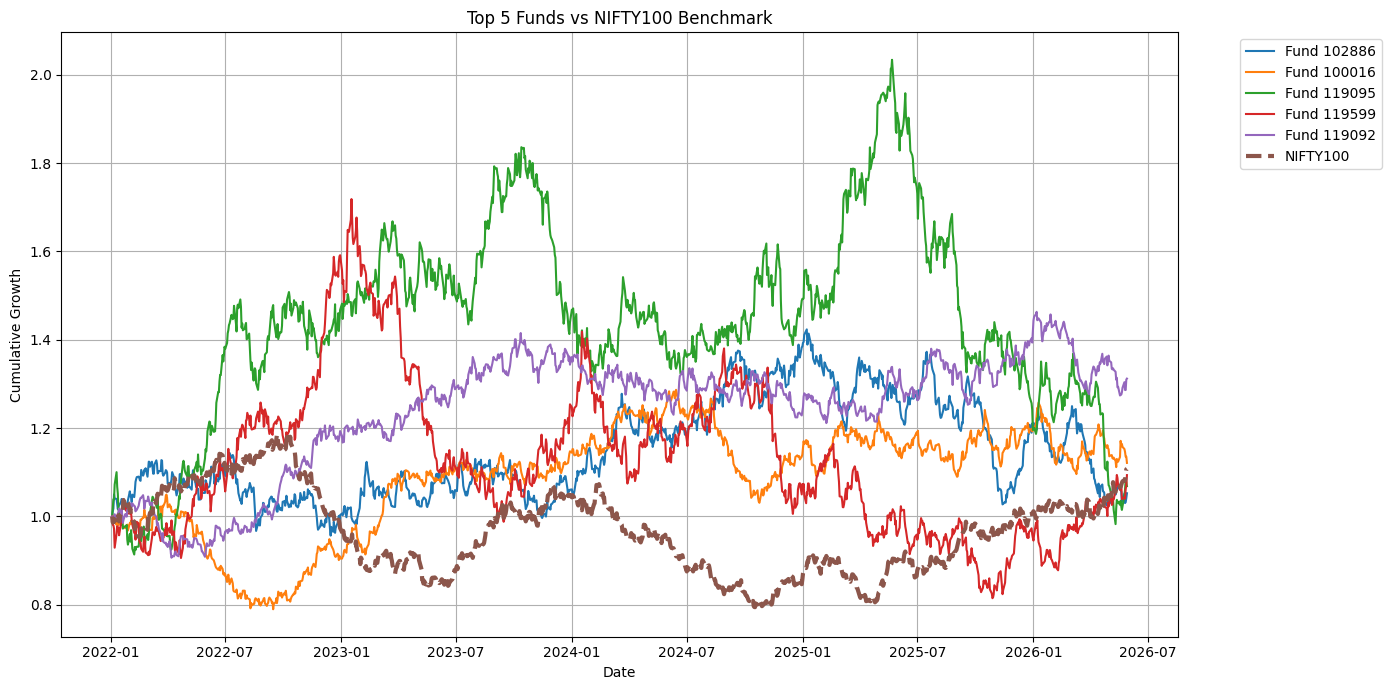

In [45]:
plt.figure(figsize=(14,7))

for fund in top5:

    temp = nav[
        nav['amfi_code'].astype(str) == fund
    ].copy()

    temp = temp.sort_values('date')

    cumulative = (
        temp['daily_return']
        .fillna(0)
        .add(1)
        .cumprod()
    )

    plt.plot(
        temp['date'],
        cumulative,
        label=f"Fund {fund}"
    )


nifty = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty = nifty.sort_values('date')

nifty_cumulative = (
    nifty['benchmark_return']
    .fillna(0)
    .add(1)
    .cumprod()
)

plt.plot(
    nifty['date'],
    nifty_cumulative,
    linewidth=3,
    linestyle='--',
    label='NIFTY100'
)

plt.title(
    "Top 5 Funds vs NIFTY100 Benchmark"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Growth")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_chart.png",
    bbox_inches='tight'
)

plt.show()

In [46]:
import os

print(
    "benchmark_chart.png" in
    os.listdir("../reports/charts")
)

True
